In [1]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

data = np.load('datavsp_01.npy')


(array([[ 3.,  7., 13., ..., 14.,  0.,  0.],
        [ 3.,  7., 13., ..., 12.,  0.,  0.],
        [ 3.,  4., 15., ..., 12.,  1.,  0.],
        ...,
        [ 0.,  0.,  4., ...,  0.,  0.,  0.],
        [ 0.,  0.,  3., ...,  0.,  0.,  0.],
        [ 0.,  0.,  3., ...,  0.,  0.,  0.]]),
 array([-0.13299546, -0.10426896, -0.07554246, -0.04681597, -0.01808947,
         0.01063702,  0.03936352,  0.06809001,  0.09681651,  0.125543  ,
         0.1542695 ]),
 <a list of 330 BarContainer objects>)

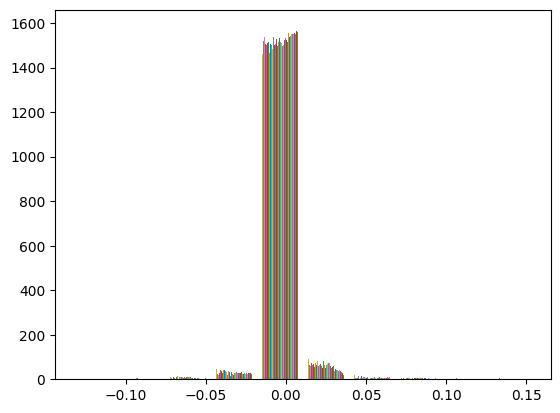

In [2]:
plt.hist(np.array(data).T)

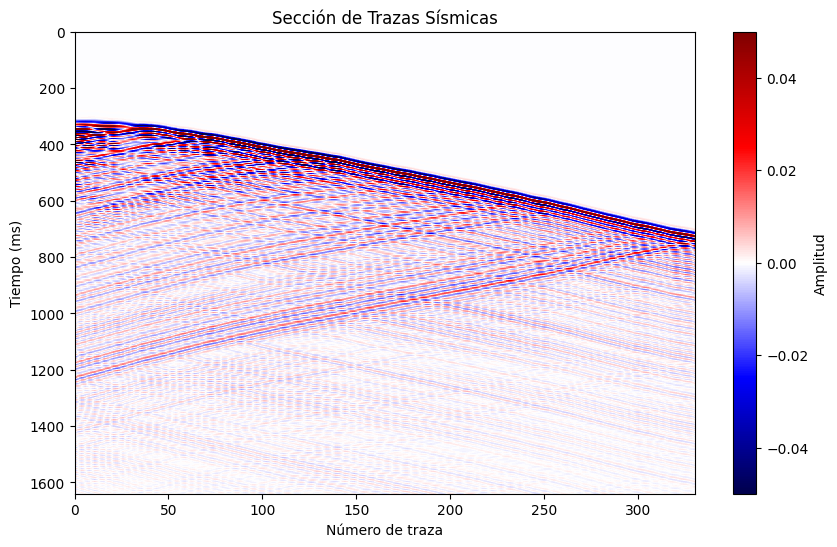

In [3]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data.T, aspect='auto', cmap='seismic', extent=[0, 330, 1640, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

In [4]:
data.shape

(330, 1624)

## Primeros arribos

In [5]:
import numpy as np

def detectar_primer_arribo(traza, umbral):
    for i, amplitud in enumerate(traza):
        if abs(amplitud) > umbral:
            return i
    return None  # No se detectó un primer arribo

# Definir el umbral
umbral = 0.05 # se define a partir del histograma

In [6]:
detectar_primer_arribo(data[329], umbral)

718

In [7]:
primeros_arribos=[]
for i in range(330):
    b=detectar_primer_arribo(data[i],umbral)
    primeros_arribos.append(b)
    

primeros_arribos

[341,
 341,
 341,
 341,
 341,
 328,
 342,
 344,
 352,
 354,
 355,
 331,
 331,
 330,
 330,
 330,
 330,
 330,
 330,
 331,
 331,
 333,
 354,
 None,
 None,
 None,
 None,
 None,
 349,
 358,
 342,
 341,
 340,
 332,
 331,
 331,
 331,
 331,
 332,
 332,
 340,
 340,
 341,
 342,
 343,
 344,
 345,
 346,
 347,
 349,
 350,
 352,
 353,
 353,
 347,
 347,
 348,
 349,
 350,
 350,
 352,
 352,
 354,
 355,
 356,
 357,
 358,
 358,
 359,
 360,
 360,
 361,
 362,
 363,
 365,
 366,
 368,
 369,
 370,
 371,
 372,
 374,
 374,
 375,
 376,
 377,
 378,
 379,
 381,
 383,
 384,
 385,
 386,
 388,
 389,
 390,
 392,
 393,
 394,
 396,
 397,
 398,
 399,
 401,
 402,
 403,
 405,
 406,
 407,
 408,
 409,
 410,
 411,
 412,
 413,
 414,
 415,
 416,
 417,
 418,
 419,
 421,
 422,
 423,
 424,
 425,
 426,
 427,
 428,
 429,
 430,
 432,
 433,
 434,
 435,
 436,
 437,
 438,
 439,
 440,
 442,
 444,
 453,
 447,
 456,
 458,
 459,
 461,
 463,
 464,
 458,
 459,
 460,
 461,
 463,
 464,
 465,
 467,
 468,
 469,
 470,
 471,
 473,
 474,
 476,
 485,

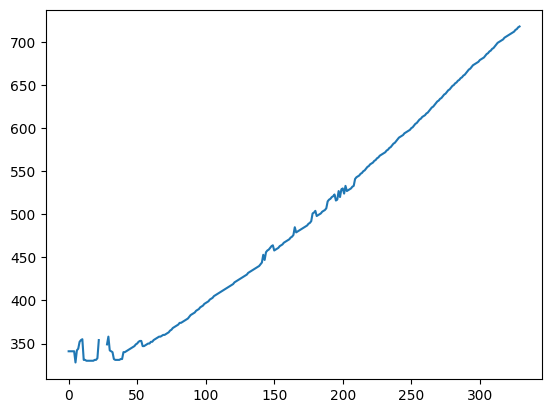

In [8]:
plt.plot(primeros_arribos)

Se va a calcular la diferencia entre los primeros arribos vecimos para definir cuando hay una anomalía

In [9]:
delta_pick = []  
for i in range(1, len(primeros_arribos)):
    if primeros_arribos[i-1] is not None and primeros_arribos[i] is not None:
        delta = primeros_arribos[i-1] - primeros_arribos[i]
        delta_pick.append(delta) 
    else:
        delta_pick.append(None)  

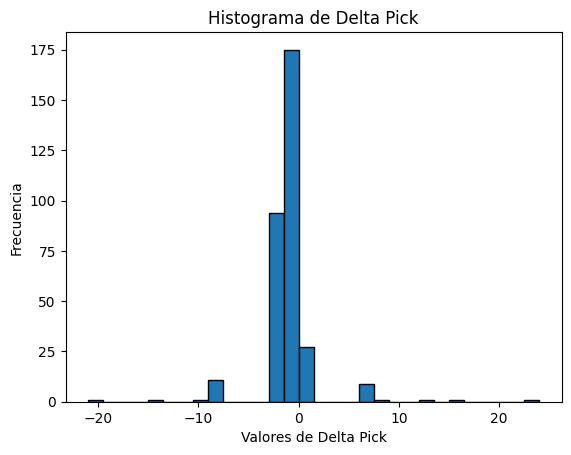

In [10]:
# Filtramos los valores None de delta_pick
delta_pick_filtered = [value for value in delta_pick if value is not None]

# Crear el histograma
plt.hist(delta_pick_filtered, bins=30, edgecolor='black')
plt.xlabel('Valores de Delta Pick')
plt.ylabel('Frecuencia')
plt.title('Histograma de Delta Pick')
plt.show()

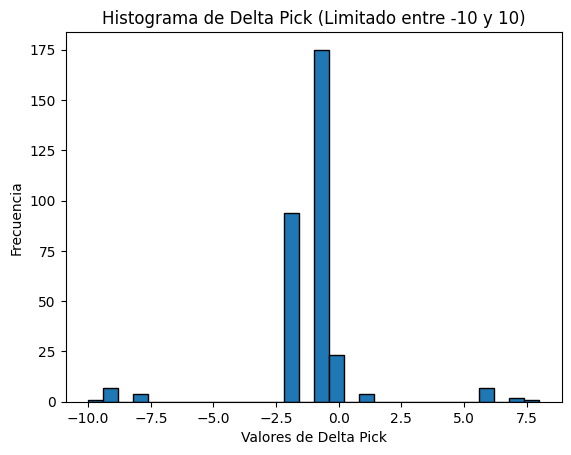

In [11]:

# Filtrar valores entre -10 y 10 
delta_pick_filtered = [value for value in delta_pick if value is not None and -10 <= value <= 10]

# Crear el histograma
plt.hist(delta_pick_filtered, bins=30, edgecolor='black')
plt.xlabel('Valores de Delta Pick')
plt.ylabel('Frecuencia')
plt.title('Histograma de Delta Pick (Limitado entre -10 y 10)')
plt.show()

In [12]:

delta_pick_filtered = [value for value in delta_pick if value is not None]

# Calculamos los cuartiles
q1 = np.percentile(delta_pick_filtered, 25)  # Primer cuartil (Q1)
q2 = np.percentile(delta_pick_filtered, 50)  # Mediana o segundo cuartil (Q2)
q3 = np.percentile(delta_pick_filtered, 75)  # Tercer cuartil (Q3)

print("Primer cuartil (Q1):", q1)
print("Mediana (Q2):", q2)
print("Tercer cuartil (Q3):", q3)

Primer cuartil (Q1): -2.0
Mediana (Q2): -1.0
Tercer cuartil (Q3): -1.0


In [15]:
indices = []
umbral = 2 # Definimos el umbral fuera del bucle para mayor claridad
for i in range(len(delta_pick)):
    if delta_pick[i] is None or abs(delta_pick[i]) > umbral:
        indices.append(i+1)

In [16]:
primeros_arribos_edit=primeros_arribos
for i in indices:
    primeros_arribos_edit[i]=None

Establecemos que porcentaje de arribos sobreviven despues de pasar por el umbral

In [17]:
porcentaje_arribos=100*(len(primeros_arribos)-len(indices))/len(primeros_arribos)
porcentaje_arribos

90.0

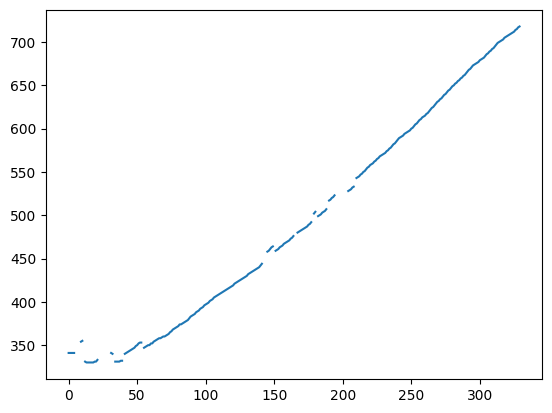

In [18]:
plt.plot(primeros_arribos_edit)

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Convertir la lista a un DataFrame de pandas para facilitar el manejo
df = pd.DataFrame({'index': range(len(primeros_arribos_edit)), 'value': primeros_arribos_edit})

In [20]:
# Filtrar los valores conocidos (no None) y los índices donde hay valores faltantes
known_values = df[df['value'].notna()]
missing_values = df[df['value'].isna()]
# Preparar los datos para el modelo
X_train = known_values[['index']]  # Índices de los valores conocidos
y_train = known_values['value']     # Valores conocidos

model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [21]:
# Predecir los valores faltantes
X_missing = missing_values[['index']]  # Índices donde los valores son None
df.loc[df['value'].isna(), 'value'] = model.predict(X_missing)

In [23]:
# Convertir el DataFrame de nuevo a lista si se necesita
primeros_arribos_edit_filled = df['value'].tolist()

print(primeros_arribos_edit_filled)

[341.0, 341.0, 341.0, 341.0, 341.0, 341.09, 343.34, 344.0, 346.82, 354.0, 355.0, 346.92, 331.0, 330.0, 330.0, 330.0, 330.0, 330.0, 330.0, 331.0, 331.0, 333.0, 332.07, 332.07, 332.07, 332.29, 335.07, 339.49, 339.43, 339.35, 339.35, 341.0, 340.0, 337.64, 331.0, 331.0, 331.0, 331.0, 332.0, 332.0, 334.56, 340.0, 341.0, 342.0, 343.0, 344.0, 345.0, 346.0, 347.0, 349.0, 350.0, 352.0, 353.0, 353.0, 351.42, 347.0, 348.0, 349.0, 350.0, 350.0, 352.0, 352.0, 354.0, 355.0, 356.0, 357.0, 358.0, 358.0, 359.0, 360.0, 360.0, 361.0, 362.0, 363.0, 365.0, 366.0, 368.0, 369.0, 370.0, 371.0, 372.0, 374.0, 374.0, 375.0, 376.0, 377.0, 378.0, 379.0, 381.0, 383.0, 384.0, 385.0, 386.0, 388.0, 389.0, 390.0, 392.0, 393.0, 394.0, 396.0, 397.0, 398.0, 399.0, 401.0, 402.0, 403.0, 405.0, 406.0, 407.0, 408.0, 409.0, 410.0, 411.0, 412.0, 413.0, 414.0, 415.0, 416.0, 417.0, 418.0, 419.0, 421.0, 422.0, 423.0, 424.0, 425.0, 426.0, 427.0, 428.0, 429.0, 430.0, 432.0, 433.0, 434.0, 435.0, 436.0, 437.0, 438.0, 439.0, 440.0, 442

In [24]:
df.loc[df['value'].isna()]

,index,value


In [25]:
# Convertir primeros arribos en tiempo si se usa frecuencia de muestreo conocida
frecuencia_muestreo = 0.001  # ms 
tiempos_primeros_arribos = [arribo * frecuencia_muestreo if arribo is not None else None for arribo in primeros_arribos]

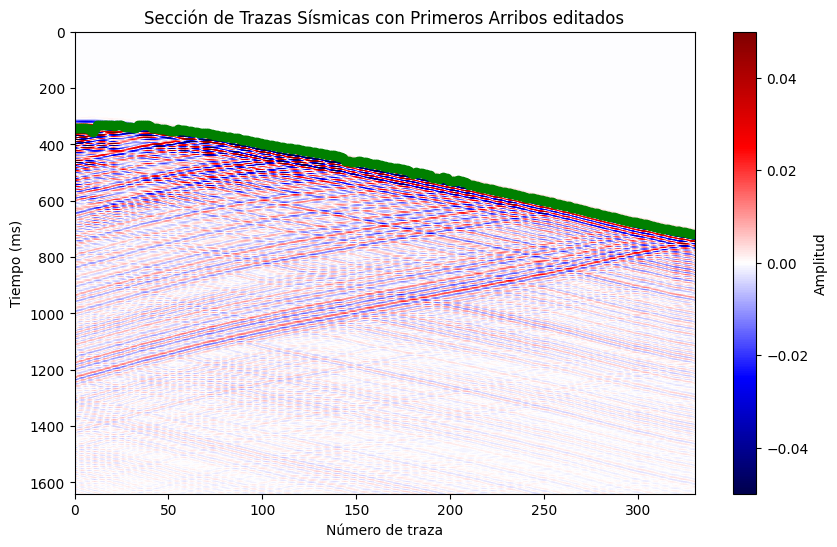

In [26]:
# Configuración para graficar las trazas sísmicas
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data.T, aspect='auto', cmap='seismic', extent=[0, 330, 1640, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")


for i, tiempo in enumerate(primeros_arribos_edit_filled):
    if tiempo is not None:
        plt.plot(i, tiempo, 'go')  # Marca en verde cada primer arribo detectado




plt.title("Sección de Trazas Sísmicas con Primeros Arribos editados")
plt.show()

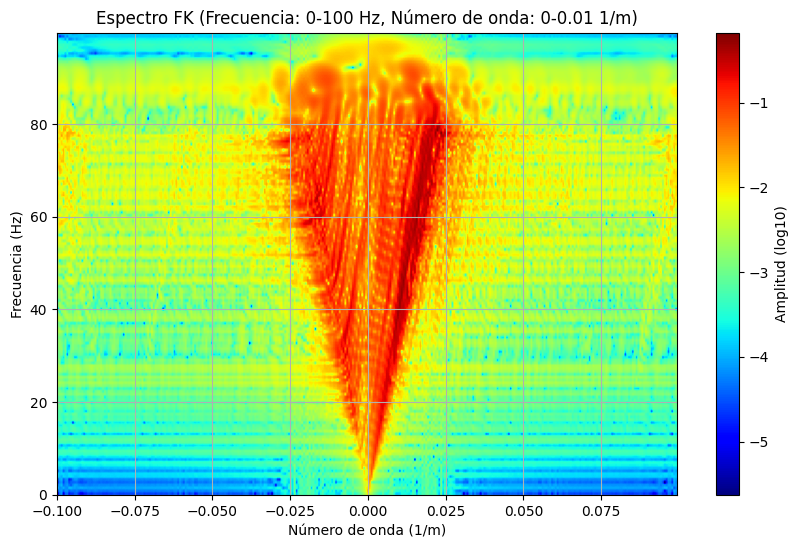

In [28]:
dt = 0.001  # Intervalo temporal en segundos (1 ms)
dx = 5 #Intervalo espacial 5m 
# Calcula la transformada de Fourier 2D
#Aqui calcula la transformada de Fourier 2D haciendo primero en el eje t y después en el eje x
#En teoria p
fk_transform = np.fft.fft(data.T,axis=0)
fk_transform = np.fft.ifft(fk_transform,axis=1)
# Reordena la transformada de Fourier en el eje x (k) para que los números de onda positivos queden a la izquierda 
fk_transform=np.fft.fftshift(fk_transform, axes=(1,))
# Magnitud del espectro
magnitude = np.abs(fk_transform)
magnitude_log =np.log10(magnitude + 1e-12)

nt, nx = data.T.shape
freqs = np.fft.fftfreq(nt, dt)  # Frecuencias (Hz)
wavenumbers = np.fft.fftfreq(nx, dx)  # Números de onda (1/m)
wavenumbers=np.fft.fftshift(wavenumbers)
# Filtrar frecuencias y números de onda positivos
freqs_positive = freqs[freqs >= 0]  # Filtrar frecuencias positivas
###wavenumbers_positive = wavenumbers[(wavenumbers >= 0) ]  # Filtrar números de onda hasta 0.11

# Seleccionar magnitudes correspondientes
fk_magnitude_log = magnitude_log[:len(freqs_positive),:]

# Limitar frecuencias a 100 Hz
freq_limit = freqs_positive[freqs_positive <= 100]
fk_magnitude_log = fk_magnitude_log[:len(freq_limit), :]

# Graficar el espectro FK acotado (amplitud logarítmica)
plt.figure(figsize=(10, 6))
extent = [wavenumbers.min(), wavenumbers.max(), freq_limit.min(), freq_limit.max()]
plt.imshow(fk_magnitude_log, aspect='auto', extent=extent, origin='lower', cmap='jet')
plt.colorbar(label='Amplitud (log10)')
plt.xlabel('Número de onda (1/m)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Espectro FK (Frecuencia: 0-100 Hz, Número de onda: 0-0.01 1/m)')
plt.grid()
plt.show()

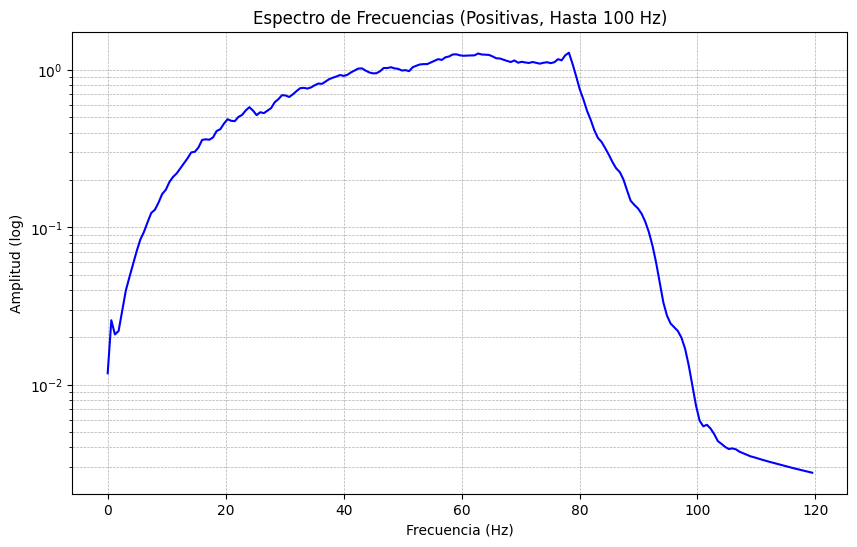

In [29]:
# Transformada de Fourier 1D (eje temporal para cada traza)
freq_transform = np.fft.fft(data.T, axis=0)

# Magnitud promedio del espectro
magnitude = np.abs(freq_transform).mean(axis=1)  # Promedio sobre todas las trazas

# Escala de frecuencias
nt = data.T.shape[0]
freqs = np.fft.fftfreq(nt, dt)  # Frecuencias (Hz)

# Filtrar frecuencias positivas hasta 100 Hz
positive_freqs = freqs[(freqs >= 0) & (freqs <= 120)]
positive_magnitude = magnitude[(freqs >= 0) & (freqs <= 120)]

# Graficar el espectro de frecuencias positivas (limitado a 100 Hz)
plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_magnitude, color='blue')
plt.yscale('log')  # Escala logarítmica en el eje Y
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud (log)')
plt.title('Espectro de Frecuencias (Positivas, Hasta 100 Hz)')
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

In [30]:
data.shape

(330, 1624)

In [31]:

# Parámetros
nt = data.shape[1]
nx = data.shape[0]
dt = 0.001  # s
dx = 5      # m

# Escalas de frecuencias y números de onda
freqs = np.fft.fftfreq(nt, dt)          # Frecuencias en Hz
wavenumbers = np.fft.fftfreq(nx, dx)    # Números de onda en 1/m

# Transformada 2D: primero en tiempo, luego en espacio o directamente con fft2
fk_transform = np.fft.fft2(data.T)  # data.shape = (nt, nx)

In [32]:
wavenumbers

array([ 0.        ,  0.00060606,  0.00121212,  0.00181818,  0.00242424,
        0.0030303 ,  0.00363636,  0.00424242,  0.00484848,  0.00545455,
        0.00606061,  0.00666667,  0.00727273,  0.00787879,  0.00848485,
        0.00909091,  0.00969697,  0.01030303,  0.01090909,  0.01151515,
        0.01212121,  0.01272727,  0.01333333,  0.01393939,  0.01454545,
        0.01515152,  0.01575758,  0.01636364,  0.0169697 ,  0.01757576,
        0.01818182,  0.01878788,  0.01939394,  0.02      ,  0.02060606,
        0.02121212,  0.02181818,  0.02242424,  0.0230303 ,  0.02363636,
        0.02424242,  0.02484848,  0.02545455,  0.02606061,  0.02666667,
        0.02727273,  0.02787879,  0.02848485,  0.02909091,  0.02969697,
        0.03030303,  0.03090909,  0.03151515,  0.03212121,  0.03272727,
        0.03333333,  0.03393939,  0.03454545,  0.03515152,  0.03575758,
        0.03636364,  0.0369697 ,  0.03757576,  0.03818182,  0.03878788,
        0.03939394,  0.04      ,  0.04060606,  0.04121212,  0.04

In [33]:
f_min, f_max = 5, 100    # Hz (ejemplo)
k_min, k_max = -0.1, 0    # 1/m (ejemplo)

# Crear la máscara
freq_grid = freqs[:, np.newaxis]        # (nt, 1)
wavenumber_grid = wavenumbers[np.newaxis, :]  # (1, nx)

mask = (freq_grid >= f_min) & (freq_grid <= f_max) & \
       (wavenumber_grid >= k_min) & (wavenumber_grid <= k_max)

# Aplicar el filtro
fk_filtered = fk_transform * mask

In [37]:
data_filtered = np.fft.ifft2(fk_filtered).real

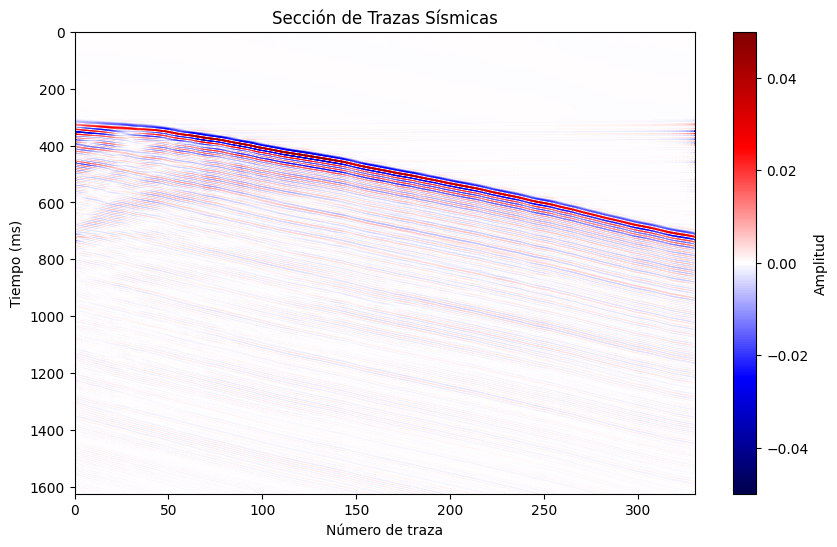

In [38]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

In [48]:
data_filtered.shape

(1624, 330)

In [45]:
data_filtered.T[0][400]

0.015290986140134771

In [47]:
primeros_arribos_edit_filled[0]

341.0

In [56]:
data_filtered_new=data_filtered.T*0

In [60]:
for i in range(data_filtered.shape[1]):
    
    for j in range(data_filtered.shape[0]):
        if j>primeros_arribos_edit_filled[i]-50:
            data_filtered_new[i][j]=data_filtered.T[i][j]
    
        


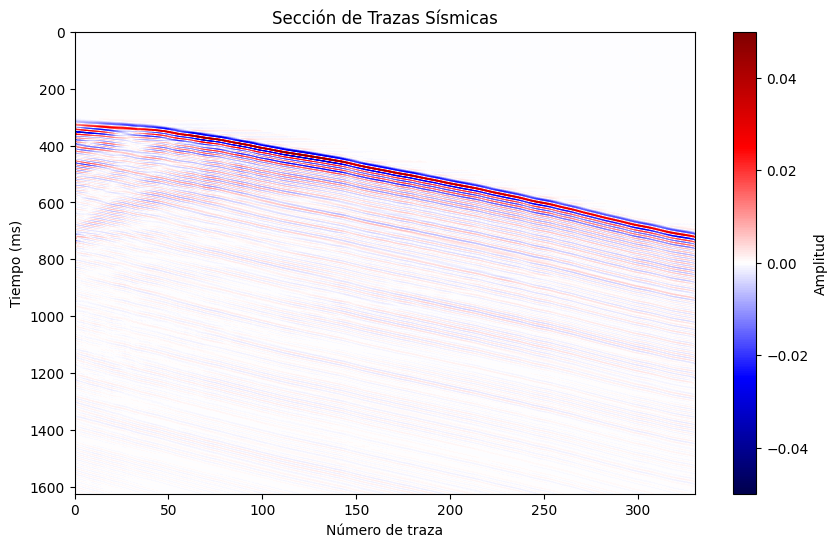

In [61]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered_new.T, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

In [63]:
f_min, f_max = 5, 100    # Hz (ejemplo)
k_min, k_max = 0, 1    # 1/m (ejemplo)

# Crear la máscara
freq_grid = freqs[:, np.newaxis]        # (nt, 1)
wavenumber_grid = wavenumbers[np.newaxis, :]  # (1, nx)

mask = (freq_grid >= f_min) & (freq_grid <= f_max) & \
       (wavenumber_grid >= k_min) & (wavenumber_grid <= k_max)

# Aplicar el filtro
fk_filtered = fk_transform * mask
data_filtered = np.fft.ifft2(fk_filtered).real

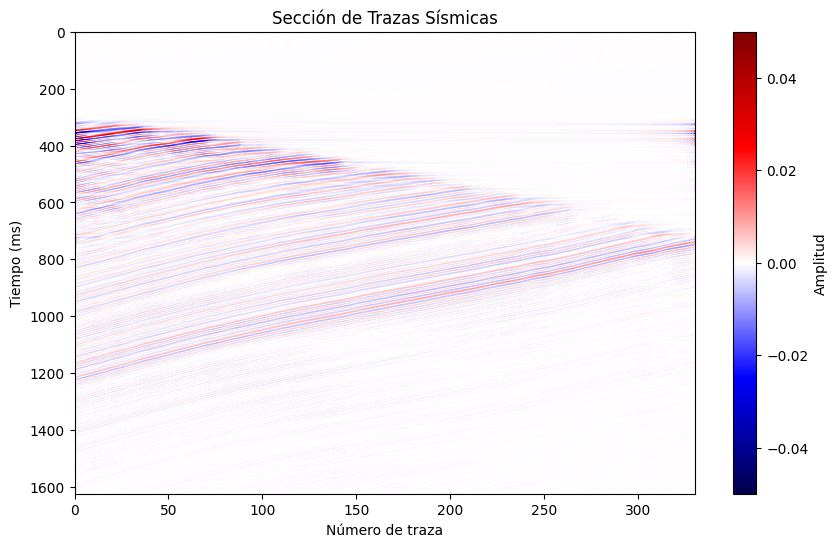

In [64]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

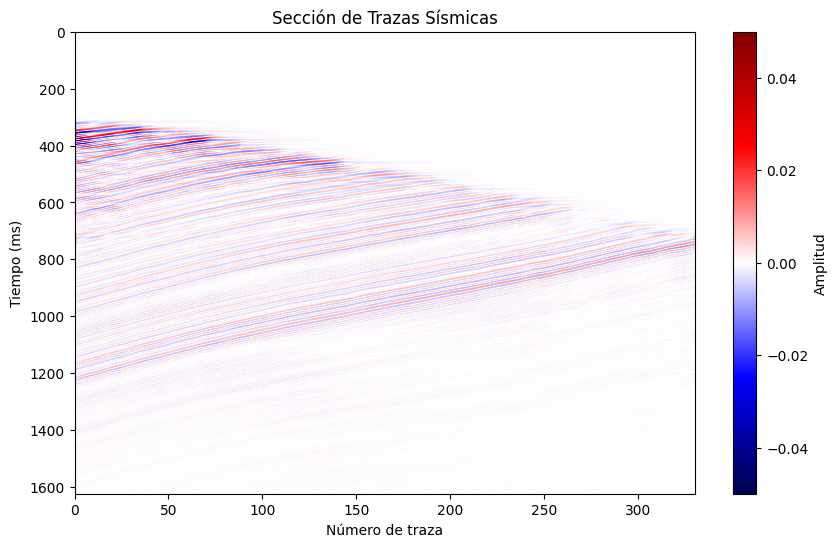

In [65]:
data_filtered_new=data_filtered.T*0
for i in range(data_filtered.shape[1]):
    
    for j in range(data_filtered.shape[0]):
        if j>primeros_arribos_edit_filled[i]-50:
            data_filtered_new[i][j]=data_filtered.T[i][j]
            
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered_new.T, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

## Crear poligono

In [66]:
F, K = np.meshgrid(wavenumbers, freqs) # F.shape = (nt, nx), K.shape = (nt, nx)


In [67]:
polygon_points = [
    (0.012, 90),
    (0.035, 90),
    (0, 0)
    
]


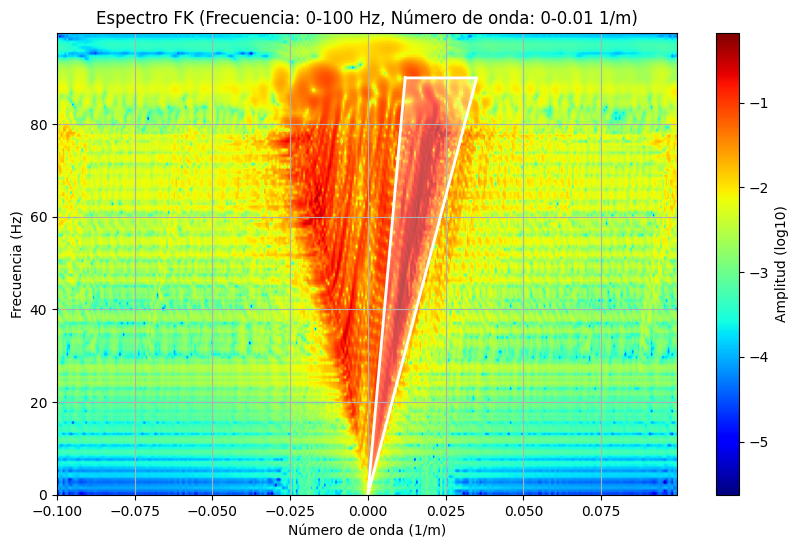

In [69]:
# Graficar el espectro FK acotado (amplitud logarítmica)
plt.figure(figsize=(10, 6))
extent = [wavenumbers.min(), wavenumbers.max(), freq_limit.min(), freq_limit.max()]
plt.imshow(fk_magnitude_log, aspect='auto', extent=extent, origin='lower', cmap='jet')
plt.colorbar(label='Amplitud (log10)')
plt.xlabel('Número de onda (1/m)')
plt.ylabel('Frecuencia (Hz)')
plt.title('Espectro FK (Frecuencia: 0-100 Hz, Número de onda: 0-0.01 1/m)')
plt.grid()

# Asumiendo que polygon_points es una lista de (k, f)
k_values = [p[0] for p in polygon_points]
f_values = [p[1] for p in polygon_points]

# Cerrar el polígono repitiendo el primer punto al final (opcional)
k_values.append(k_values[0])
f_values.append(f_values[0])

# Ahora superponemos el polígono en la gráfica ya generada
plt.plot(k_values, f_values, color='white', linewidth=2)  # Línea del polígono
# Opcionalmente, rellenar el polígono con semitransparencia
plt.fill(k_values, f_values, color='white', alpha=0.3)

# Si la gráfica ya estaba mostrada con plt.show(), será necesario volver a llamarlo
plt.show()

In [82]:
from matplotlib.path import Path
path = Path(polygon_points)

# Prepara las coordenadas (k, f) en una sola lista de puntos
points = np.vstack((F.ravel(), K.ravel())).T  # Cada fila es (k, f)

# Determinar qué puntos caen dentro del polígono
mask_polygon = path.contains_points(points)

# Darle forma al mask para que coincida con (nt, nx)
mask_polygon = mask_polygon.reshape(F.shape) 


In [83]:
fk_filtered = fk_transform * mask_polygon ## incluye los puntos dentro del poligono


In [41]:
##fk_filtered = fk_transform * (~mask_polygon) ## excluye los puntos dentro del poligono

In [84]:
data_filtered = np.fft.ifft2(fk_filtered).real


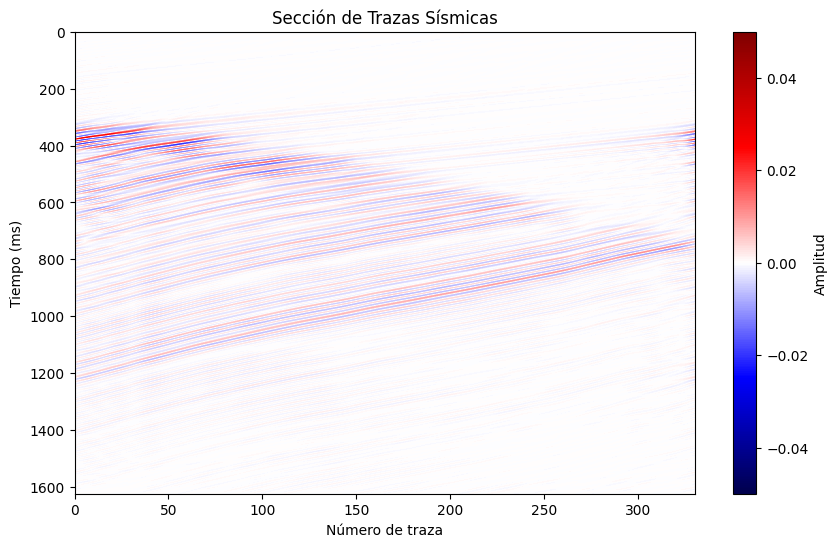

In [85]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

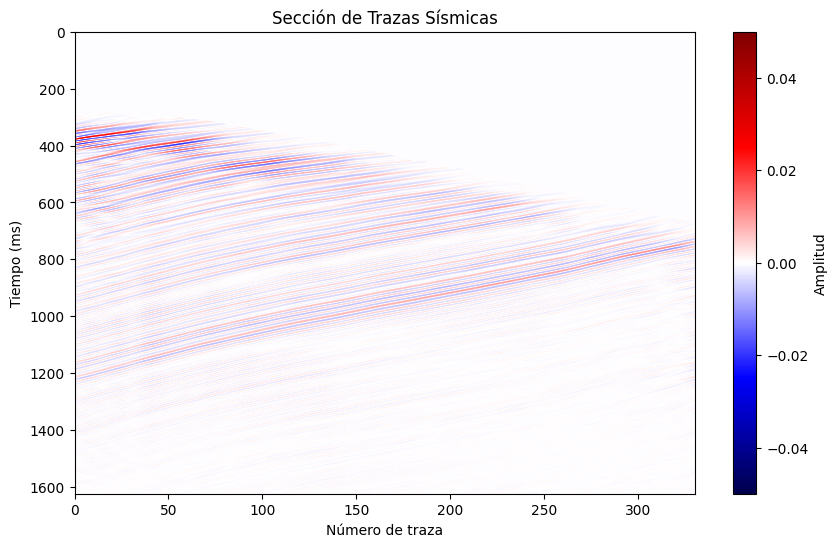

In [86]:
data_filtered_new=data_filtered.T*0
for i in range(data_filtered.shape[1]):
    
    for j in range(data_filtered.shape[0]):
        if j>primeros_arribos_edit_filled[i]-50:
            data_filtered_new[i][j]=data_filtered.T[i][j]
            
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(data_filtered_new.T, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()

In [89]:
resta=data-data_filtered_new

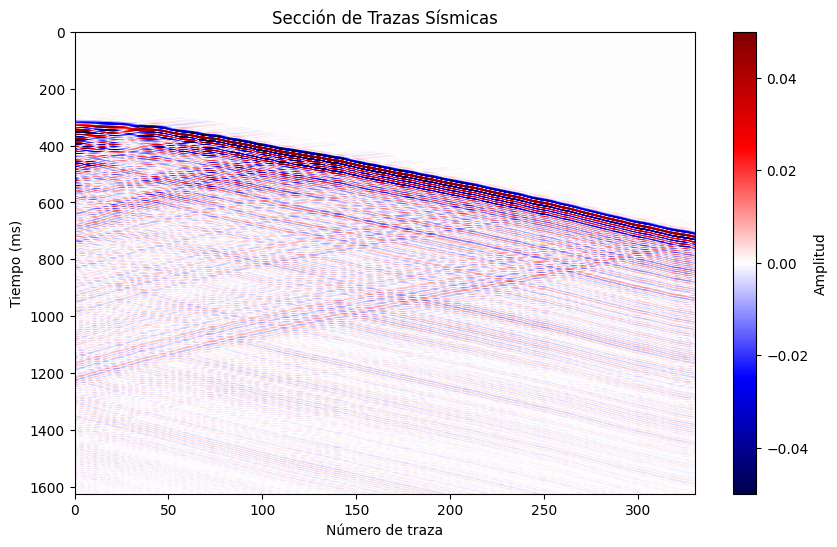

In [91]:
# Configuración para graficar las trazas sísmicas
clip = 5e-2
vmin, vmax = -clip, clip
plt.figure(figsize=(10, 6))
plt.imshow(resta.T, aspect='auto', cmap='seismic', extent=[0, nx, nt, 0], vmin=vmin, vmax=vmax)
plt.colorbar(label="Amplitud")
plt.xlabel("Número de traza")
plt.ylabel("Tiempo (ms)")
plt.title("Sección de Trazas Sísmicas")
plt.show()